In [1]:
%pip install -q otter-grader

Note: you may need to restart the kernel to use updated packages.


# In-Class Exercise 02: Distances, Norms and Similarity

**DS701 — Session 3 (Mon Sep 14, 2026) — Section A1**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/class_activity_notebooks/02-InClass-Exercise-Distances-A1/02-InClass-Exercise-Distances-A1.ipynb)

**Time: ~40 minutes.** Work in groups of 2–3.

Parts marked **(autograded)** are submitted to Gradescope; open-ended parts are graded
for participation. You may use AI assistance, but you must be able to explain and
justify every part of your solution when asked.

**Plan**

| Part | Topic | Grading | Time |
|---|---|---|---|
| 1 | Distance functions and a distance matrix, by hand | autograded | ~15 min |
| 2 | Verify against `scipy` / `sklearn`; check the metric axioms | autograded | ~8 min |
| 3 | Metric choice and feature scaling change the neighbors | autograded | ~12 min |
| 4 | Wrap-up: which distance for which data? | participation | ~3 min |

Dependencies: `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`.

## Setup

We use the classic **wine** dataset that ships with `scikit-learn`: 178 wines, 13
chemical measurements each (alcohol, malic acid, ..., proline), and a label `y` in
$\{0, 1, 2\}$ giving the grape cultivar. We will **not** use `y` to compute anything —
distances are unsupervised — but we will peek at it to judge whether a distance is
putting "similar" wines near each other.

The activity works on a random subset of 60 wines.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.datasets import load_wine
from sklearn.metrics import pairwise

In [5]:
# Lecture section. Only A1 runs this semester; this is kept because the build
# script reads it to name the variant directory the notebook is published in.
SECTION = "A1"
SEED = 701
rng = np.random.default_rng(SEED)

In [6]:
# Colab: fetch the autograder tests for this activity.
import os, sys, urllib.request

if "google.colab" in sys.modules:
    os.makedirs("tests", exist_ok=True)
    BASE = "https://raw.githubusercontent.com/tools4ds/DS701-Materials-FA26/main/class_activity_notebooks/02-InClass-Exercise-Distances-A1/tests/"
    for _q in ("q1", "q2", "q3"):
        urllib.request.urlretrieve(BASE + _q + ".py", "tests/" + _q + ".py")

In [7]:
# Initialize Otter
import otter
grader = otter.Notebook()

In [8]:
wine = load_wine()
feature_names = list(wine.feature_names)

# Each section gets its own 60-wine subset (a seeded permutation of the 178 rows).
subset = rng.permutation(len(wine.data))[:60]
X = wine.data[subset]          # (60, 13) real-valued measurements
y = wine.target[subset]        # cultivar 0/1/2 -- for peeking only
n, d = X.shape

# One wine we will keep asking about: "who are its nearest neighbors?"
QUERY = 0

# A binary version for the set-based distances: 1 if the wine is above the
# subset median on that feature. Row i is then the SET of features on which
# wine i is "high".
B = (X > np.median(X, axis=0)).astype(int)

print(f"section {SECTION}: X is {X.shape}, B is {B.shape}, query wine has cultivar {y[QUERY]}")
pd.DataFrame(X[:5], columns=feature_names).round(2)

section A1: X is (60, 13), B is (60, 13), query wine has cultivar 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
1,12.51,1.73,1.98,20.5,85.0,2.20,1.92,0.32,1.48,2.94,1.04,3.57,672.0
2,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
3,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0
4,12.77,2.39,2.28,19.5,86.0,1.39,0.51,0.48,0.64,9.90,0.57,1.63,470.0


Look at the table above before you compute anything: `proline` is in the hundreds,
`hue` is around 1. Keep that in mind for Part 3.

## Part 1 (autograded): distance functions, by hand

Recall the definitions from the lecture. For $\mathbf{u}, \mathbf{v} \in \mathbb{R}^d$:

$$
\Vert\mathbf{u}-\mathbf{v}\Vert_p = \Big(\sum_i |u_i - v_i|^p\Big)^{1/p},\qquad
d_{\cos}(\mathbf{u},\mathbf{v}) = 1 - \frac{\mathbf{u}\cdot\mathbf{v}}{\Vert\mathbf{u}\Vert_2\,\Vert\mathbf{v}\Vert_2},\qquad
d_{J}(a, b) = 1 - \frac{|a \cap b|}{|a \cup b|}
$$

**Task.** Implement the four functions below with `numpy` only — no `scipy`, no `sklearn`
in this part. The point is to know exactly what the library does before you call it.

- `lp_distance(u, v, p)` — the Minkowski / $\ell_p$ distance for any `p >= 1`
  (`p = 1` is Manhattan, `p = 2` is Euclidean). You may treat `p = np.inf` as a bonus.
- `cosine_distance(u, v)` — $1 - \cos(\mathbf{u}, \mathbf{v})$.
- `jaccard_distance(a, b)` — for two 0/1 vectors that represent sets: 1 minus
  intersection-over-union. Convention: two empty sets have distance 0.
- `distance_matrix(X, dist)` — the $n \times n$ matrix `D[i, j] = dist(X[i], X[j])`
  for any two-argument distance function `dist`. A double loop is fine here.

Return plain Python `float`s from the first three (wrap with `float(...)`).

In [ ]:
def lp_distance(u, v, p=2):
    """Minkowski distance ||u - v||_p for p >= 1 (p = np.inf gives Chebyshev)."""
    u, v = np.asarray(u, dtype=float), np.asarray(v, dtype=float)
    lp_dist = np.linalg.norm(u - v, ord=p)
    return lp_dist


def cosine_distance(u, v):
    """1 - cos(u, v)."""
    u, v = np.asarray(u, dtype=float), np.asarray(v, dtype=float)
    cosine_dist = 1 - np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return cosine_dist


def jaccard_distance(a, b):
    """1 - |a & b| / |a | b| for 0/1 vectors a, b (sets). Two empty sets -> 0."""
    a, b = np.asarray(a).astype(bool), np.asarray(b).astype(bool)
    jaccard_dist = 1 - np.sum(a & b) / np.sum(a | b) if np.any(a | b) else 0.0
    return jaccard_dist


def distance_matrix(X, dist):
    """D[i, j] = dist(X[i], X[j]) for every pair of rows of X."""
    X = np.asarray(X)
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = dist(X[i], X[j])
    return D


# The lecture's warm-up: A = (3, 4), B = (1, 1)
A_pt, B_pt = np.array([3.0, 4.0]), np.array([1.0, 1.0])
print("l1 =", lp_distance(A_pt, B_pt, 1), " l2 =", round(lp_distance(A_pt, B_pt, 2), 4),
      " linf =", lp_distance(A_pt, B_pt, np.inf))


l1 = 5.0  l2 = 3.6056  linf = 3.0


In [15]:
grader.check("q1")

q1 results: All test cases passed!

## Part 2 (autograded): verify against the libraries, and check the axioms

Now build the four $60 \times 60$ distance matrices for the wine subset and confirm you
agree with the professionals.

**Task.**

1. `D_euc`, `D_man`, `D_cos` from **your** `distance_matrix` on `X`, and `D_jac` on the
   binary matrix `B`.
2. The reference versions with `sklearn.metrics.pairwise.euclidean_distances`,
   `manhattan_distances`, `cosine_distances` (all take a single `X`), and
   `scipy.spatial.distance.cdist(B, B, 'jaccard')`. Store the **largest absolute
   difference** between yours and the reference in `err_euc`, `err_man`, `err_cos`,
   `err_jac` — each should be tiny (`< 1e-8`).
3. Write `axiom_report(D)` returning a dict with three booleans —
   `{'zero_diag': ..., 'symmetric': ..., 'triangle': ...}` — where `triangle` is `True`
   iff $D_{ij} \le D_{ik} + D_{kj}$ holds for **every** triple $(i, j, k)$ (allow a
   `1e-9` tolerance). Vectorize it: `D[:, :, None] <= D[:, None, :] + D[None, :, :]`
   is the whole check in one line.
4. Store `axioms_cos = axiom_report(D_cos)`.

Then think: the lecture claims $1 - \cos$ is **not** a metric. Does your `axioms_cos`
*prove* that, disprove it, or neither? (Discuss in your group; Part 4 asks you to write
it down.)

In [20]:
D_euc = distance_matrix(X, lambda u, v: lp_distance(u, v, 2))
D_man = distance_matrix(X, lambda u, v: lp_distance(u, v, 1))
D_cos = distance_matrix(X, cosine_distance)
D_jac = distance_matrix(B, jaccard_distance)

ref_euc = pairwise.euclidean_distances(X)
ref_man = pairwise.manhattan_distances(X)
ref_cos = pairwise.cosine_distances(X)
ref_jac = cdist(B, B, metric='jaccard')

err_euc = np.max(np.abs(D_euc - ref_euc))
err_man = np.max(np.abs(D_man - ref_man))
err_cos = np.max(np.abs(D_cos - ref_cos))
err_jac = np.max(np.abs(D_jac - ref_jac))

print(f"max |mine - library|:  euclid {err_euc:.2e}  manhattan {err_man:.2e}  cosine {err_cos:.2e}  jaccard {err_jac:.2e}")


def axiom_report(D, tol=1e-9):
    """Which metric axioms does the matrix D satisfy?"""
    D = np.asarray(D, dtype=float)
    zero_diag = np.allclose(np.diag(D), 0, atol=tol)
    symmetric = np.allclose(D, D.T, atol=tol)
    triangle = bool(np.all(D[:, :, None] <= D[:, None, :] + D[None, :, :] + tol))
    return {'zero_diag': zero_diag, 'symmetric': symmetric, 'triangle': triangle}

axioms_cos = axiom_report(D_cos)
for name, D in [("euclidean", D_euc), ("manhattan", D_man), ("cosine", D_cos), ("jaccard", D_jac)]:
    print(f"{name:>10}: {axiom_report(D)}")

[[   0.          778.50032036   30.09196903 ...  820.21156771
   180.28933302 1070.44994736]
 [ 778.50032036    0.          808.51395696 ...   43.07466541
   598.26426602  292.034788  ]
 [  30.09196903  808.51395696    0.         ...  850.22875439
   210.30197526 1100.46228713]
 ...
 [ 820.21156771   43.07466541  850.22875439 ...    0.
   640.05893401  250.35040843]
 [ 180.28933302  598.26426602  210.30197526 ...  640.05893401
     0.          890.24593827]
 [1070.44994736  292.034788   1100.46228713 ...  250.35040843
   890.24593827    0.        ]]
[[   0.    820.08   35.84 ...  849.92  194.5  1117.62]
 [ 820.08    0.    851.46 ...   58.34  626.54  302.94]
 [  35.84  851.46    0.   ...  882.52  226.6  1147.68]
 ...
 [ 849.92   58.34  882.52 ...    0.    657.08  277.28]
 [ 194.5   626.54  226.6  ...  657.08    0.    924.26]
 [1117.62  302.94 1147.68 ...  277.28  924.26    0.  ]]
[[ 0.00000000e+00  1.42855776e-03  1.10936037e-06 ...  2.75115593e-03
   8.83996610e-06  1.04341407e-02]
 [ 

In [21]:
grader.check("q2")

q2 results: All test cases passed!

#### Cosine doesn't satisfy the property that distance has to adhere to triangle rule. We found a counter example where triangle inequality doesn't hold. 

## Part 3 (autograded): the metric changes the neighbors — and so do the units

A distance matrix is only interesting for what we do with it, and the first thing we
do is ask **who is near whom**.

**Task 3a — metric choice.** Write `nearest(D, i, k)` returning the indices of the `k`
nearest neighbors of row `i` according to matrix `D`, closest first, **excluding `i`
itself**. Then fill the dict `nn_by_metric` with the 5 nearest neighbors of `QUERY`
under each of `'euclidean'`, `'manhattan'`, `'cosine'`, `'jaccard'` (use your matrices
from Part 2). Look at how much the four lists agree.

**Task 3b — a fair scoreboard.** One neighbor list is an anecdote. Write
`loo_1nn_accuracy(D, y)`: for every wine, find its single nearest neighbor (not itself)
and check whether that neighbor has the same cultivar; return the fraction of wines
for which it does. This is *leave-one-out 1-nearest-neighbor accuracy* — a number that
says how well a distance groups "similar" things, using labels only to *score*.
Store `acc_raw = loo_1nn_accuracy(D_euc, y)`.

**Task 3c — scaling.** Standardize by hand: `X_std = (X - X.mean(axis=0)) / X.std(axis=0)`
(population std, `ddof=0`). Recompute the Euclidean matrix on `X_std` as `D_euc_std`,
and store `acc_std = loo_1nn_accuracy(D_euc_std, y)` and
`nn_std = nearest(D_euc_std, QUERY, 5)`. Finally set `dominant_feature` to the **name**
of the feature whose variance is the largest share of the total variance in `X`
(look at `X.var(axis=0)`), and `dominant_share` to that share (a float in $[0,1]$).

 euclidean: neighbors [ 2 38 53 19 34]  cultivars [0, 0, 0, 0, 0]  (query is 0)
 manhattan: neighbors [ 2 53 38 19 34]  cultivars [0, 0, 0, 0, 0]  (query is 0)
    cosine: neighbors [ 2 58 34 53 17]  cultivars [0, 0, 0, 0, 0]  (query is 0)
   jaccard: neighbors [54 58 20 17 16]  cultivars [0, 0, 0, 0, 0]  (query is 0)
[[0.         5.52990207 1.92966806 ... 5.1728504  1.9647915  6.57370674]
 [5.52990207 0.         6.12193636 ... 2.8884989  4.66829631 4.39353228]
 [1.92966806 6.12193636 0.         ... 6.25986093 2.88098665 6.46531021]
 ...
 [5.1728504  2.8884989  6.25986093 ... 0.         4.7328861  6.41682338]
 [1.9647915  4.66829631 2.88098665 ... 4.7328861  0.         5.510242  ]
 [6.57370674 4.39353228 6.46531021 ... 6.41682338 5.510242   0.        ]]

LOO 1-NN accuracy, Euclidean:  raw 0.650   standardized 1.000
neighbors of the query, standardized Euclidean: [54 34  2 58 53]  cultivars [0, 0, 0, 0, 0]
'proline' alone carries 99.7% of the total variance


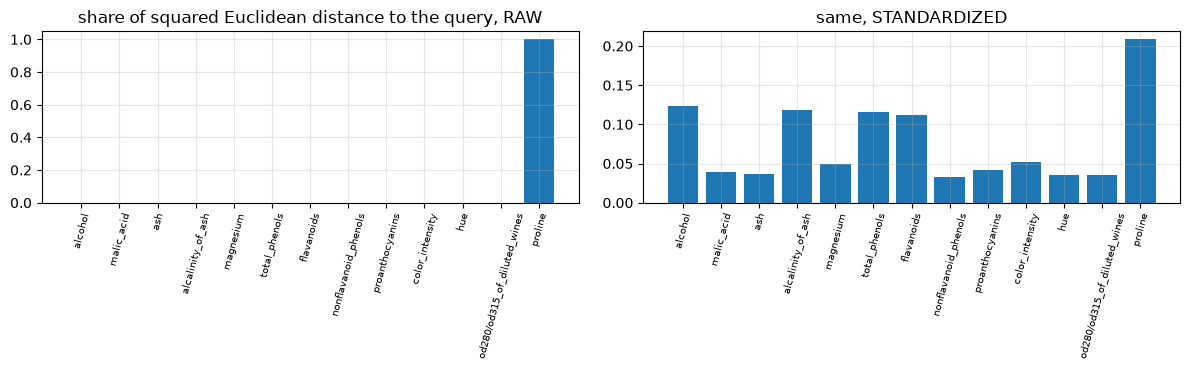

In [31]:
def nearest(D, i, k):
    """Indices of the k nearest rows to row i under D, closest first, excluding i."""
    D = np.asarray(D)
    ordered_indices = np.argsort(D[i])
    ordered_indices = ordered_indices[ordered_indices != i]  # Exclude the query itself
    return ordered_indices[:k]


def loo_1nn_accuracy(D, y):
    """Fraction of rows whose nearest OTHER row (under D) shares its label."""
    D=np.array(D)
    n=D.shape[0]
    matches = [y[nearest(D, i, 1)[0]] == y[i] for i in range(n)]
    return float(np.mean(matches))


# 3a
nn_by_metric = {}
for m, D in [('euclidean', D_euc), ('manhattan', D_man), ('cosine', D_cos), ('jaccard', D_jac)]:
    nn_by_metric[m] = nearest(D, QUERY, 5)
for m, idx in nn_by_metric.items():
    print(f"{m:>10}: neighbors {idx}  cultivars {y[idx].tolist()}  (query is {y[QUERY]})")

# 3b
acc_raw = loo_1nn_accuracy(D_euc, y)

# 3c
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
D_euc_std = distance_matrix(X_std, lambda u, v: lp_distance(u, v, 2))
acc_std = loo_1nn_accuracy(D_euc_std, y)
nn_std = nearest(D_euc_std, QUERY, 5)

var_share = X.var(axis=0) / X.var(axis=0).sum()
dominant_feature = feature_names[np.argmax(var_share)]
dominant_share = var_share.max()

print(f"\nLOO 1-NN accuracy, Euclidean:  raw {acc_raw:.3f}   standardized {acc_std:.3f}")
print(f"neighbors of the query, standardized Euclidean: {nn_std}  cultivars {y[nn_std].tolist()}")
print(f"{dominant_feature!r} alone carries {100 * dominant_share:.1f}% of the total variance")

# Where does the raw Euclidean distance from the query actually come from?
contrib = ((X - X[QUERY]) ** 2).sum(axis=0)
contrib_s = ((X_std - X_std[QUERY]) ** 2).sum(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(range(d), contrib / contrib.sum()); axes[0].set_title('share of squared Euclidean distance to the query, RAW')
axes[1].bar(range(d), contrib_s / contrib_s.sum()); axes[1].set_title('same, STANDARDIZED')
for ax in axes:
    ax.set_xticks(range(d)); ax.set_xticklabels(feature_names, rotation=75, fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Discuss (participation, 2 minutes):** before standardizing, the query's five nearest
wines under Euclidean and under Manhattan were nearly the same list, and the bar chart on
the left is one tall bar. Explain both facts with one sentence about `proline`.

*(your sentence here)*
Proline is an abundint amino acid in wine, it's scale is much larger than any other feature. So it dominated the euclidean and manhattan disrance. The metrics end up ranking wines by proline. 

In [32]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

## Part 4 (open-ended, participation): which distance for which data?

Staff will circulate and ask your group to explain your reasoning — have your screen and
your numbers ready. Write brief answers here:

1. Your `axiom_report(D_cos)` from Part 2 — did it *prove* that $1 - \cos$ is not a
   metric, disprove it, or neither? What would it take to settle the question? 
   \
   It proved that cos is not a metric

2. Under which distance (Euclidean, Manhattan, cosine, Jaccard, raw or standardized) did
   the query's neighbors share its cultivar most often, and *why do you think* that one
   worked best on chemical measurements? 
   \ 
   Standardised is the best on chemical measurements because it doesn't let proline dominate like the other raw metrics.
3. Give one dataset you know where you would reach for **cosine** first and one for
   **Jaccard** — one phrase each on why.
   \
   **Cosine**: text-embeddings when looking for word similarity or semantic meaning between different docs
   \
   **Jaccard:** document deduplication when the number od similar words is as important as number of dissimilar words

_Type your answer here, replacing this text._

<!-- END QUESTION -->

## Wrap-up

Before you leave, each group should be able to answer:

1. State the four metric axioms, and name one "distance" from today that fails one of them.
2. Why did standardizing change the neighbors so much on this dataset, and would cosine
   distance have avoided the problem on its own?

Submit your completed notebook to Gradescope.